<a href="https://colab.research.google.com/github/danpele/2024-XAI-Intro/blob/main/ATSSB_Stylized_Facts_ARCH/ATSSB_Stylized_Facts_ARCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

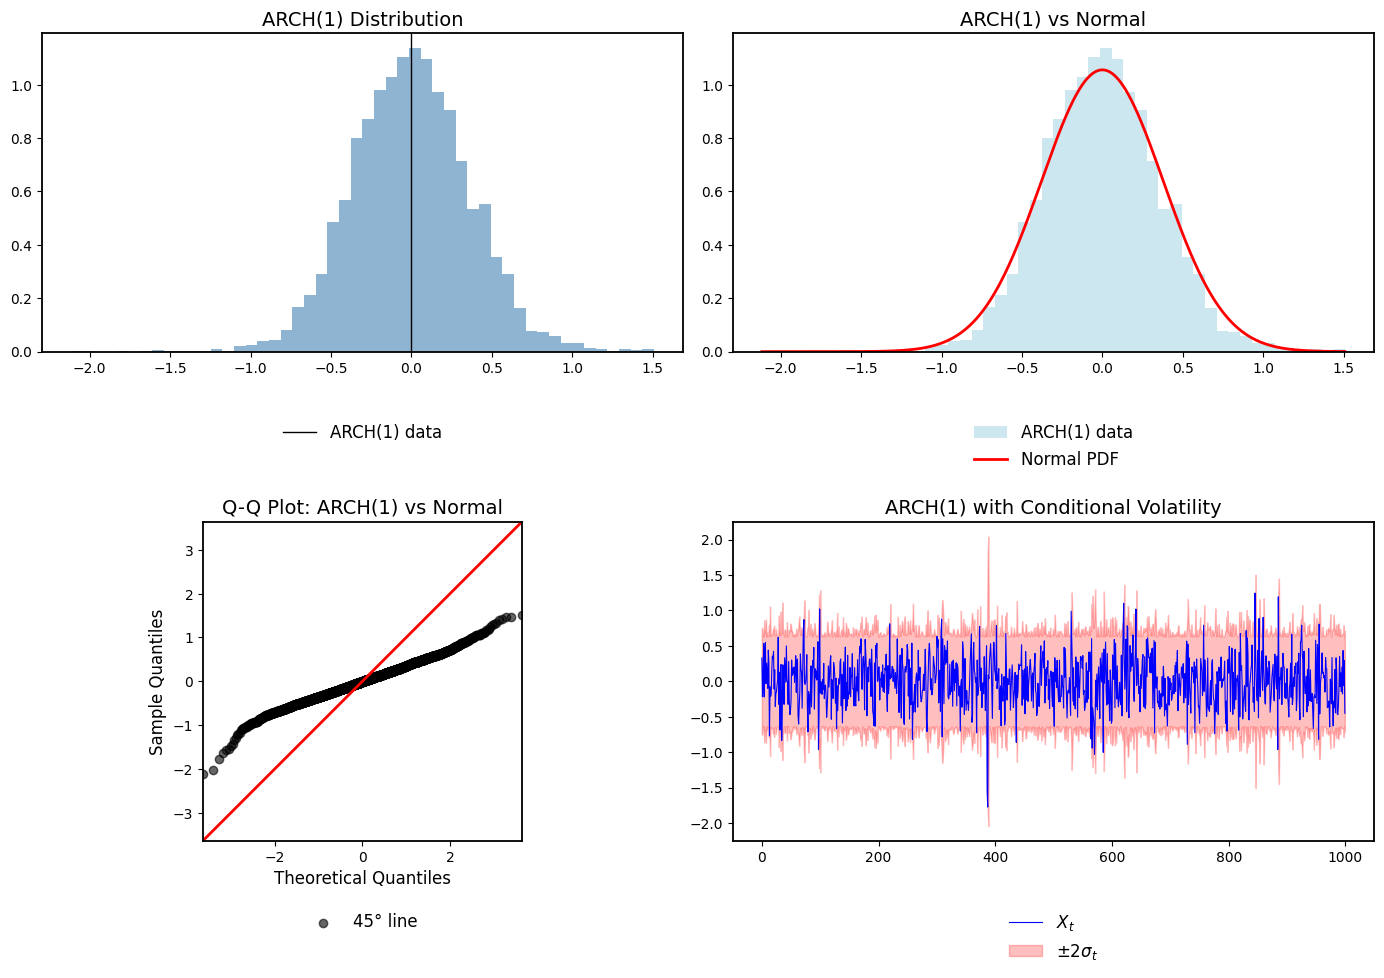

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.grid'] = False


class ARCH1ProofDemo:

    def __init__(self, omega=0.1, alpha1=0.3, n_sim=5000):
        self.omega = omega
        self.alpha1 = alpha1
        self.n_sim = n_sim
        self.theoretical_variance = omega / (1 - alpha1)
        self.theoretical_kurtosis = 3 * (1 - alpha1**2) / (1 - 3*alpha1**2)

    def simulate_arch1(self):
        X = np.zeros(self.n_sim)
        sigma_sq = np.zeros(self.n_sim)
        eps = np.random.standard_normal(self.n_sim)

        sigma_sq[0] = self.theoretical_variance
        X[0] = np.sqrt(sigma_sq[0]) * eps[0]

        for t in range(1, self.n_sim):
            sigma_sq[t] = self.omega + self.alpha1 * X[t-1]**2
            X[t] = np.sqrt(sigma_sq[t]) * eps[t]

        return X, sigma_sq

    def plot_results(self):

        X, sigma_sq = self.simulate_arch1()

        fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                                 facecolor='none')
        fig.patch.set_alpha(0)

        # -------------------------------
        # (1) Kurtosis histogram
        # -------------------------------
        kurt_ratio = (X**4).mean() / (X**2).mean()**2

        axes[0,0].hist(X, bins=50, density=True,
                       alpha=0.6, color='steelblue')

        axes[0,0].axvline(0, color='black', linewidth=1)

        axes[0,0].set_title("ARCH(1) Distribution")
        axes[0,0].set_facecolor('none')

        # Legend outside bottom
        axes[0,0].legend(
            ["ARCH(1) data"],
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            frameon=False
        )

        # -------------------------------
        # (2) Histogram vs Normal
        # -------------------------------
        axes[0,1].hist(X, bins=50, density=True,
                       alpha=0.6, color='lightblue',
                       label="ARCH(1) data")

        x_range = np.linspace(X.min(), X.max(), 1000)
        normal_pdf = stats.norm.pdf(
            x_range, 0,
            np.sqrt(self.theoretical_variance)
        )

        axes[0,1].plot(x_range, normal_pdf,
                       color='red', linewidth=2,
                       label="Normal PDF")

        axes[0,1].set_title("ARCH(1) vs Normal")
        axes[0,1].set_facecolor('none')

        axes[0,1].legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            frameon=False
        )

        # -------------------------------
        # (3) Q-Q plot (square + identical axes)
        # -------------------------------
        osm, osr = stats.probplot(X, dist="norm", fit=False)

        ax = axes[1,0]
        ax.scatter(osm, osr, color='black', alpha=0.6)

        bound = max(np.abs(osm).max(), np.abs(osr).max())
        ax.set_xlim(-bound, bound)
        ax.set_ylim(-bound, bound)

        ax.plot([-bound, bound], [-bound, bound],
                color='red', linewidth=2)

        ax.set_box_aspect(1)
        ax.set_title("Q-Q Plot: ARCH(1) vs Normal")
        ax.set_xlabel("Theoretical Quantiles")
        ax.set_ylabel("Sample Quantiles")
        ax.set_facecolor('none')

        # Legend outside bottom
        ax.legend(
            ["45° line"],
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            frameon=False
        )

        # -------------------------------
        # (4) Time series with ±2σ_t
        # -------------------------------
        axes[1,1].plot(X[:1000],
                       color='blue',
                       linewidth=0.8,
                       label=r"$X_t$")

        axes[1,1].fill_between(
            range(1000),
            2*np.sqrt(sigma_sq[:1000]),
            -2*np.sqrt(sigma_sq[:1000]),
            color='red',
            alpha=0.25,
            label=r"$\pm 2\sigma_t$"
        )

        axes[1,1].set_title("ARCH(1) with Conditional Volatility")
        axes[1,1].set_facecolor('none')

        axes[1,1].legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.18),
            frameon=False
        )

        # -------------------------------
        # Styling: remove grid + clean spines
        # -------------------------------
        for ax in axes.flatten():
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_linewidth(1.3)
                spine.set_color('black')
            ax.tick_params(labelsize=10)

        plt.tight_layout()
        plt.savefig(
            "arch1_clean_publication.png",
            dpi=300,
            bbox_inches='tight',
            transparent=True
        )
        plt.show()


# Run
demo = ARCH1ProofDemo()
demo.plot_results()